In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from collections import Counter

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [ ]:
def add_technical_indicators(df):
    close = df['Close']
    high = df['High']
    low = df['Low']

    df['SMA_7'] = close.rolling(7).mean()
    df['SMA_21'] = close.rolling(21).mean()

    delta = close.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-10)
    df['RSI'] = 100 - (100 / (1 + rs))

    ema12 = close.ewm(span=12).mean()
    ema26 = close.ewm(span=26).mean()
    df['MACD'] = ema12 - ema26
    df['MACD_signal'] = df['MACD'].ewm(span=9).mean()

    sma20 = close.rolling(20).mean()
    std20 = close.rolling(20).std()
    df['BB_pct'] = (close - (sma20 - 2*std20)) / ((sma20 + 2*std20) - (sma20 - 2*std20) + 1e-10)

    tr = pd.concat([high - low, (high - close.shift()).abs(), (low - close.shift()).abs()], axis=1).max(axis=1)
    df['ATR_pct'] = tr.rolling(14).mean() / close

    df['Vol_ratio'] = df['Volume'] / df['Volume'].rolling(14).mean()
    df['Returns_1d'] = close.pct_change()
    df['Returns_5d'] = close.pct_change(5)
    return df

FEATURE_COLS = ['RSI', 'MACD', 'ATR_pct', 'Vol_ratio', 'Returns_1d', 'Returns_5d']

def get_bitcoin_data():
    #btc = pd.read_csv('data/Bitcoin_1_1_2015-1_1_2025_historical_data_coinmarketcap.csv')
    btc = pd.read_csv('bitcoin_2018-01-01_2026-03-12.csv') #, header =0, sep=';')
    btc = btc.iloc[::-1].reset_index(drop=True)
    btc = add_technical_indicators(btc)
    btc = btc.dropna().reset_index(drop=True)
    data = btc[FEATURE_COLS].values
    close_prices = btc['Close'].values
    return data, btc, close_prices

def create_sequences(data, close_prices, sequence_length=60):
    X, y, y_close = [], [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, :])
        ret = np.log(close_prices[i] / close_prices[i-1])
        y.append(ret)
        y_close.append(close_prices[i])
    return np.array(X), np.array(y), np.array(y_close)

sequence_length = 100
raw_data, raw_df, close_prices = get_bitcoin_data()
X, y, y_close = create_sequences(raw_data, close_prices, sequence_length)
print(f"Total sequences: {X.shape[0]}, Features per timestep: {X.shape[2]}")
print(f"Target (daily log return) — mean: {y.mean()*100:.3f}%, std: {y.std()*100:.3f}%")

Total sequences: 2872, Features per timestep: 6
Target (daily log return) — mean: 0.071%, std: 3.315%


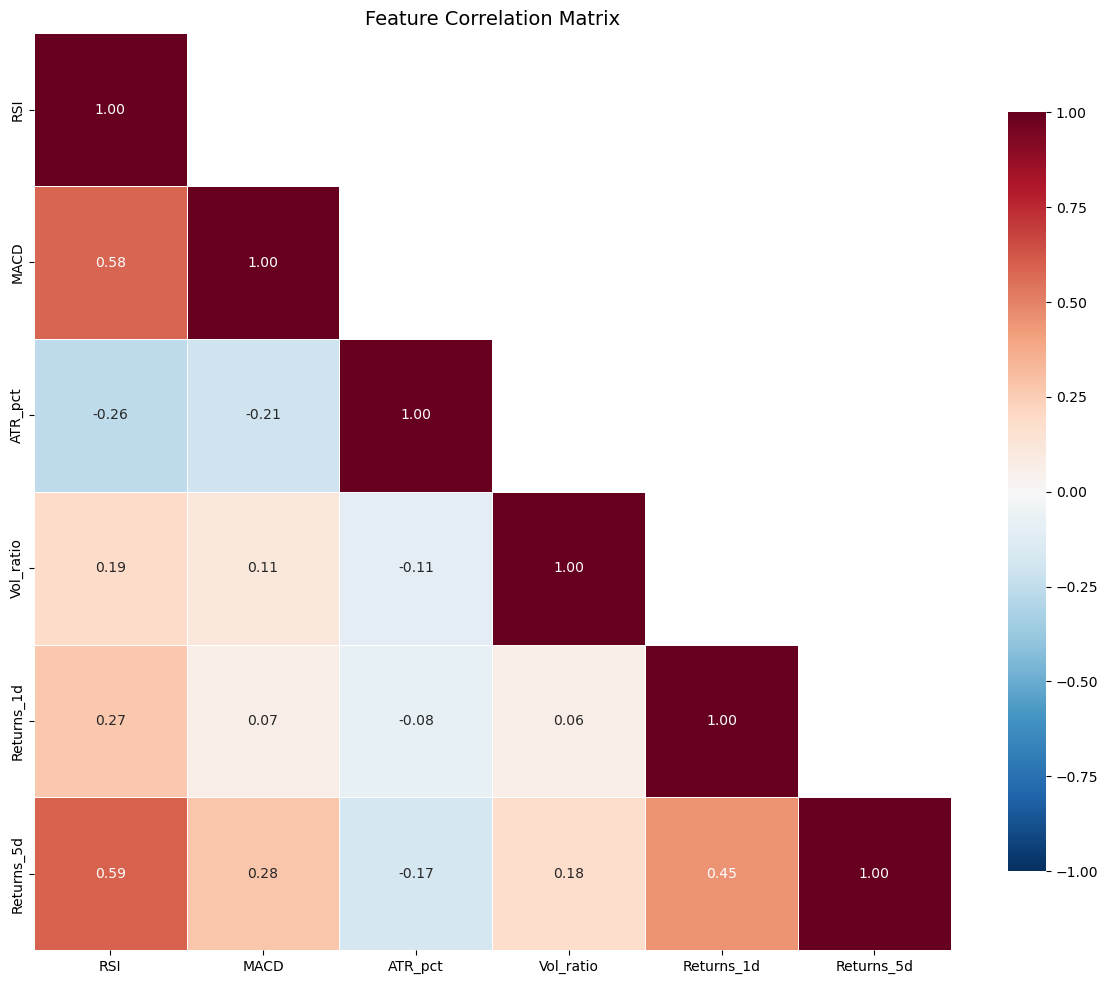

In [ ]:
import seaborn as sns

corr_df = raw_df[FEATURE_COLS].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── VSN + LSTM Model Definition ──

class VariableSelectionNetwork(nn.Module):
    """
    Variable Selection Network (VSN) inspired by the Temporal Fusion Transformer.
    Each covariate is independently embedded via a learnable nonlinear function.
    A gating network computes softmax attention weights over all feature embeddings,
    producing a dynamically weighted representations.
    """
    def __init__(self, num_features, embed_dim, dropout=0.1):
        super().__init__()
        self.num_features = num_features
        self.embed_dim = embed_dim

        # φ_i: per-feature nonlinear embedding
        self.feature_embeddings = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1, embed_dim),
                nn.ReLU(),
                nn.Linear(embed_dim, embed_dim),
                nn.Dropout(dropout),
            )
            for _ in range(num_features)
        ])

        # gating network: softmax(W_g [h_1,...,h_C] + b_g)
        self.gate = nn.Sequential(
            nn.Linear(num_features * embed_dim, num_features),
            # softmax applied in forward()
        )

    def forward(self, x):
        """
        x : (batch, seq_len, num_features)
        returns: (batch, seq_len, embed_dim)
        """
        B, L, C = x.shape

        # Embed each feature independently → list of (B, L, embed_dim)
        h = [self.feature_embeddings[i](x[:, :, i:i+1]) for i in range(C)]
        h_stack = torch.stack(h, dim=2)            # (B, L, C, embed_dim)
        h_cat = h_stack.reshape(B, L, C * self.embed_dim)  # (B, L, C*E)

        # Gating weights  (Eq. 45)
        alpha = F.softmax(self.gate(h_cat), dim=-1)  # (B, L, C)

        # Weighted sum  (Eq. 46)
        alpha_exp = alpha.unsqueeze(-1)               # (B, L, C, 1)
        x_tilde = (alpha_exp * h_stack).sum(dim=2)    # (B, L, embed_dim)
        return x_tilde, alpha


class VLSTM(nn.Module):
    """
    VSN + LSTM  (VLSTM).
    
    1. VSN produces dynamically weighted feature embeddings x̃_t = VSN(x_t)  (Eq. 47)
    2. LSTM aggregates temporal information: (h_t, c_t) = LSTM(x̃_t, h_{t-1}, c_{t-1})  (Eq. 48)
    3. Prediction from final hidden state: ŷ_{L+1} = W_o h_L + b_o  (Eq. 49)
    """
    def __init__(self, num_features=15, embed_dim=32, hidden_dim=64,
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.vsn = VariableSelectionNetwork(num_features, embed_dim, dropout)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x_tilde, alpha = self.vsn(x)          # (B, L, embed_dim), (B, L, C)
        out, _ = self.lstm(x_tilde)            # (B, L, hidden_dim)
        last = self.dropout(out[:, -1, :])     # (B, hidden_dim)
        return self.fc(last), alpha            # prediction, gate weights


In [75]:
X, y, y_close = create_sequences(raw_data, close_prices, sequence_length)
X.shape

(2872, 100, 6)

In [ ]:
from collections import Counter

raw_data, raw_df, close_prices = get_bitcoin_data()


# config
TRAIN_WINDOW = 900          # fixed sliding window: always train on last 900 days
HOLD_OUT_DAYS = 100         # predict last 100 days
STEP_SIZE = 5               # retrain every 5 days
FINETUNE_PATIENCE = 12
FINETUNE_EPOCHS = 40
LR = 0.0005
WEIGHT_DECAY = 1e-5
OUTPUT_CLIP = 0.06          # bound predictions to +/- 6% daily log return
N = len(X)
test_start = N - HOLD_OUT_DAYS

print(f"Total sequences: {N}")
print(f"Sliding training window: {TRAIN_WINDOW} days")
print(f"Test period: last {HOLD_OUT_DAYS} days (index {test_start} → {N})")
print(f"Step size: {STEP_SIZE} days per window")
print(f"Number of retraining windows: {(HOLD_OUT_DAYS + STEP_SIZE - 1) // STEP_SIZE}")

wf_pred_returns = []
wf_actual_returns = []
wf_close_prices = []
wf_alpha_weights = []
wf_window_losses = []

num_features = X.shape[2]
window_count = 0

# base model 
base_model = VLSTM(num_features=num_features, embed_dim=32, hidden_dim=64,
                   num_layers=2, dropout=0.2).to(device)

for wf_start in range(test_start, N, STEP_SIZE):
    wf_end = min(wf_start + STEP_SIZE, N)
    window_count += 1

    tr_begin = max(0, wf_start - TRAIN_WINDOW)
    X_tr_raw = X[tr_begin:wf_start]
    y_tr_raw = y[tr_begin:wf_start]
    X_te_raw = X[wf_start:wf_end]
    y_te_raw = y[wf_start:wf_end]
    y_close_te = y_close[wf_start:wf_end]

    if len(X_te_raw) == 0:
        break

    wf_scaler = StandardScaler()
    tr_flat = X_tr_raw.reshape(-1, num_features)
    wf_scaler.fit(tr_flat)

    X_tr_s = wf_scaler.transform(X_tr_raw.reshape(-1, num_features)).reshape(X_tr_raw.shape)
    X_te_s = wf_scaler.transform(X_te_raw.reshape(-1, num_features)).reshape(X_te_raw.shape)

    X_tr_t = torch.from_numpy(X_tr_s).float().to(device)
    y_tr_t = torch.from_numpy(y_tr_raw.reshape(-1, 1)).float().to(device)
    X_te_t = torch.from_numpy(X_te_s).float().to(device)

    # using previous weights
    wf_model = VLSTM(num_features=num_features, embed_dim=32, hidden_dim=64,
                     num_layers=2, dropout=0.2).to(device)
    wf_model.load_state_dict(base_model.state_dict())
    wf_optimizer = torch.optim.Adam(wf_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    wf_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        wf_optimizer, mode='min', factor=0.6, patience=5
    )

    # training
    best_loss = float('inf')
    patience_ctr = 0
    best_state = None

    for ep in range(FINETUNE_EPOCHS):
        wf_model.train()
        wf_optimizer.zero_grad()

        pred_raw, _ = wf_model(X_tr_t)
        pred = squash_predictions(pred_raw, clip_return=OUTPUT_CLIP)
        loss = calibrated_hybrid_loss(pred, y_tr_t)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(wf_model.parameters(), max_norm=1.0)
        wf_optimizer.step()
        wf_scheduler.step(loss)

        lv = loss.item()
        if lv < best_loss - 1e-8:
            best_loss = lv
            patience_ctr = 0
            best_state = {k: v.clone() for k, v in wf_model.state_dict().items()}
        else:
            patience_ctr += 1

        if patience_ctr >= FINETUNE_PATIENCE:
            break

    if best_state is not None:
        wf_model.load_state_dict(best_state)

    wf_model.eval()
    with torch.no_grad():
        pred_out_raw, gate_w = wf_model(X_te_t)
        pred_out = squash_predictions(pred_out_raw, clip_return=OUTPUT_CLIP)
        preds = pred_out.cpu().numpy().flatten()
        preds = preds - np.median(preds)  # remove window-level directional bias
        alphas = gate_w.cpu().numpy()

    base_model.load_state_dict(wf_model.state_dict())

    wf_pred_returns.extend(preds.tolist())
    wf_actual_returns.extend(y_te_raw.tolist())
    wf_close_prices.extend(y_close_te.tolist())
    wf_alpha_weights.append(alphas)
    wf_window_losses.append(best_loss)

    stopped = "early" if patience_ctr >= FINETUNE_PATIENCE else "max"
    print(f"Window {window_count:2d} | Train: [{tr_begin}:{wf_start}] ({len(X_tr_raw)} days) | "
          f"Test: {wf_start}→{wf_end} ({len(X_te_raw)} days) | "
          f"Loss: {best_loss:.6f} | Stopped: {stopped} @ ep {ep+1}")

wf_pred_returns = np.array(wf_pred_returns)
wf_actual_returns = np.array(wf_actual_returns)
wf_close_prices = np.array(wf_close_prices)

print(f"\n{'='*60}")
print(f"Walk-forward complete: {len(wf_pred_returns)} predictions across {window_count} windows")

Total sequences: 2872
Sliding training window: 900 days
Test period: last 100 days (index 2772 → 2872)
Step size: 5 days per window
Number of retraining windows: 20
Window  1 | Train: [1872:2772] (900 days) | Test: 2772→2777 (5 days) | Loss: 0.574446 | Stopped: early @ ep 22
Window  2 | Train: [1877:2777] (900 days) | Test: 2777→2782 (5 days) | Loss: 0.544445 | Stopped: max @ ep 40
Window  3 | Train: [1882:2782] (900 days) | Test: 2782→2787 (5 days) | Loss: 0.550463 | Stopped: early @ ep 34
Window  4 | Train: [1887:2787] (900 days) | Test: 2787→2792 (5 days) | Loss: 0.520446 | Stopped: max @ ep 40
Window  5 | Train: [1892:2792] (900 days) | Test: 2792→2797 (5 days) | Loss: 0.515199 | Stopped: early @ ep 34
Window  6 | Train: [1897:2797] (900 days) | Test: 2797→2802 (5 days) | Loss: 0.522580 | Stopped: early @ ep 15
Window  7 | Train: [1902:2802] (900 days) | Test: 2802→2807 (5 days) | Loss: 0.490665 | Stopped: max @ ep 40
Window  8 | Train: [1907:2807] (900 days) | Test: 2807→2812 (5 d

In [77]:
# ── Vanilla LSTM Model Definition ──

class VanillaLSTM(nn.Module):
    """
    Standard LSTM baseline — no variable selection, raw features go straight in.
    """
    def __init__(self, num_features, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(num_features, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)                  # (B, L, hidden_dim)
        last = self.dropout(out[:, -1, :])     # (B, hidden_dim)
        return self.fc(last)                   # (B, 1)

vanilla_model = VanillaLSTM(num_features=X.shape[2], hidden_dim=64,
                             num_layers=2, dropout=0.2).to(device)
vanilla_params = sum(p.numel() for p in vanilla_model.parameters())
print(f"Vanilla LSTM parameters: {vanilla_params:,}")
print(vanilla_model)

Vanilla LSTM parameters: 51,777
VanillaLSTM(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [78]:
# ── Vanilla LSTM Walk-Forward (same sliding window config as VLSTM) ──

# Re-use same config: TRAIN_WINDOW, HOLD_OUT_DAYS, STEP_SIZE, etc.
LR_V = 0.001
FINETUNE_EPOCHS_V = 30
FINETUNE_PATIENCE_V = 80

N = len(X)
test_start = N - HOLD_OUT_DAYS
num_features = X.shape[2]

# Storage
van_pred_returns = []
van_actual_returns = []
van_close_prices = []
van_window_losses = []
van_window_count = 0

# Base model for warm-starting
van_base = VanillaLSTM(num_features=num_features, hidden_dim=64,
                        num_layers=2, dropout=0.2).to(device)

print(f"Vanilla LSTM Walk-Forward | Train window: {TRAIN_WINDOW} | "
      f"Test: last {HOLD_OUT_DAYS} days | Step: {STEP_SIZE}\n")

for wf_start in range(test_start, N, STEP_SIZE):
    wf_end = min(wf_start + STEP_SIZE, N)
    van_window_count += 1

    tr_begin = max(0, wf_start - TRAIN_WINDOW)
    X_tr_raw = X[tr_begin:wf_start]
    y_tr_raw = y[tr_begin:wf_start]
    X_te_raw = X[wf_start:wf_end]
    y_te_raw = y[wf_start:wf_end]
    y_close_te = y_close[wf_start:wf_end]

    if len(X_te_raw) == 0:
        break

    # Scale
    v_scaler = StandardScaler()
    v_scaler.fit(X_tr_raw.reshape(-1, num_features))
    X_tr_s = v_scaler.transform(X_tr_raw.reshape(-1, num_features)).reshape(X_tr_raw.shape)
    X_te_s = v_scaler.transform(X_te_raw.reshape(-1, num_features)).reshape(X_te_raw.shape)

    X_tr_t = torch.from_numpy(X_tr_s).float().to(device)
    y_tr_t = torch.from_numpy(y_tr_raw.reshape(-1, 1)).float().to(device)
    X_te_t = torch.from_numpy(X_te_s).float().to(device)

    # Warm-start
    v_model = VanillaLSTM(num_features=num_features, hidden_dim=64,
                           num_layers=2, dropout=0.2).to(device)
    v_model.load_state_dict(van_base.state_dict())
    v_opt = torch.optim.Adam(v_model.parameters(), lr=LR_V)
    v_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(v_opt, mode='min', factor=0.5, patience=40)

    best_loss = float('inf')
    patience_ctr = 0
    best_state = None

    for ep in range(FINETUNE_EPOCHS_V):
        v_model.train()
        v_opt.zero_grad()
        pred = v_model(X_tr_t)
        loss = combined_loss(pred, y_tr_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(v_model.parameters(), max_norm=1.0)
        v_opt.step()
        v_sched.step(loss)

        lv = loss.item()
        if lv < best_loss - 1e-8:
            best_loss = lv
            patience_ctr = 0
            best_state = {k: v.clone() for k, v in v_model.state_dict().items()}
        else:
            patience_ctr += 1
        if patience_ctr >= FINETUNE_PATIENCE_V:
            break

    if best_state is not None:
        v_model.load_state_dict(best_state)

    v_model.eval()
    with torch.no_grad():
        preds = v_model(X_te_t).cpu().numpy().flatten()

    van_base.load_state_dict(v_model.state_dict())

    van_pred_returns.extend(preds.tolist())
    van_actual_returns.extend(y_te_raw.tolist())
    van_close_prices.extend(y_close_te.tolist())
    van_window_losses.append(best_loss)

    stopped = "early" if patience_ctr >= FINETUNE_PATIENCE_V else "max"
    print(f"Window {van_window_count:2d} | Train: [{tr_begin}:{wf_start}] ({len(X_tr_raw)}) | "
          f"Test: {wf_start}→{wf_end} ({len(X_te_raw)}) | "
          f"Loss: {best_loss:.6f} | {stopped} @ ep {ep+1}")

van_pred_returns = np.array(van_pred_returns)
van_actual_returns = np.array(van_actual_returns)
van_close_prices = np.array(van_close_prices)

print(f"\n{'='*60}")
print(f"Vanilla LSTM walk-forward complete: {len(van_pred_returns)} predictions across {van_window_count} windows")

Vanilla LSTM Walk-Forward | Train window: 900 | Test: last 100 days | Step: 5

Window  1 | Train: [1872:2772] (900) | Test: 2772→2777 (5) | Loss: -0.112705 | max @ ep 30
Window  2 | Train: [1877:2777] (900) | Test: 2777→2782 (5) | Loss: -0.147223 | max @ ep 30
Window  3 | Train: [1882:2782] (900) | Test: 2782→2787 (5) | Loss: -0.165202 | max @ ep 30
Window  4 | Train: [1887:2787] (900) | Test: 2787→2792 (5) | Loss: -0.199653 | max @ ep 30
Window  5 | Train: [1892:2792] (900) | Test: 2792→2797 (5) | Loss: -0.206770 | max @ ep 30
Window  6 | Train: [1897:2797] (900) | Test: 2797→2802 (5) | Loss: -0.238383 | max @ ep 30
Window  7 | Train: [1902:2802] (900) | Test: 2802→2807 (5) | Loss: -0.259086 | max @ ep 30
Window  8 | Train: [1907:2807] (900) | Test: 2807→2812 (5) | Loss: -0.281557 | max @ ep 30
Window  9 | Train: [1912:2812] (900) | Test: 2812→2817 (5) | Loss: -0.294410 | max @ ep 30
Window 10 | Train: [1917:2817] (900) | Test: 2817→2822 (5) | Loss: -0.319643 | max @ ep 30
Window 11 |

In [ ]:
wf_prices = wf_close_prices
init_cash = 10000.0
fee_pct = 0.001
stop_loss_pct = 0.10
take_profit_pct = 0.08
allocation_pct = 0.95

cash, btc_held, entry_price = init_cash, 0.0, 0.0
wf_portfolio = []
wf_buy_idx, wf_buy_px = [], []
wf_sell_idx, wf_sell_px = [], []
wf_stop_idx, wf_stop_px = [], []
wf_tp_idx, wf_tp_px = [], []

for i, (sig, p) in enumerate(zip(wf_signals, wf_prices)):
    # stop losss
    if btc_held > 0 and p <= entry_price * (1 - stop_loss_pct):
        cash += btc_held * p * (1 - fee_pct)
        btc_held = entry_price = 0.0
        wf_stop_idx.append(i)
        wf_stop_px.append(p)

    elif btc_held > 0 and p >= entry_price * (1 + take_profit_pct):
        cash += btc_held * p * (1 - fee_pct)
        btc_held = entry_price = 0.0
        wf_tp_idx.append(i)
        wf_tp_px.append(p)

    elif sig == "BUY" and btc_held == 0 and cash > 0:
        trade = cash * allocation_pct
        btc_bought = trade * (1 - fee_pct) / p
        btc_held = btc_bought
        cash -= trade
        entry_price = p
        wf_buy_idx.append(i)
        wf_buy_px.append(p)

    # sell in position
    elif sig == "SELL" and btc_held > 0:
        cash += btc_held * p * (1 - fee_pct)
        btc_held = entry_price = 0.0
        wf_sell_idx.append(i)
        wf_sell_px.append(p)

    wf_portfolio.append(cash + btc_held * p)

# force closure
if btc_held > 0:
    p = wf_prices[-1]
    cash += btc_held * p * (1 - fee_pct)
    btc_held = 0.0
    wf_sell_idx.append(len(wf_prices) - 1)
    wf_sell_px.append(p)
    wf_portfolio[-1] = cash

wf_portfolio = np.array(wf_portfolio)
wf_bh_ret = (wf_prices[-1] / wf_prices[0] - 1) * 100
wf_model_ret = (wf_portfolio[-1] / init_cash - 1) * 100

# annualized sharpe
daily_rets = np.diff(wf_portfolio) / np.maximum(wf_portfolio[:-1], 1e-8)
wf_sharpe = np.sqrt(252) * daily_rets.mean() / (daily_rets.std() + 1e-10)

peak = np.maximum.accumulate(wf_portfolio)
drawdown = (wf_portfolio - peak) / np.maximum(peak, 1e-8)
max_dd = drawdown.min() * 100

print("Walk-Forward Backtest Results")
print(f"VLSTM Strategy Return: {wf_model_ret:.2f}%")
print(f"Buy & Hold Return:     {wf_bh_ret:.2f}%")
print(f"Final Portfolio Value:  ${wf_portfolio[-1]:,.2f}")
print(f"Annualized Sharpe:     {wf_sharpe:.3f}")
print(f"Max Drawdown:          {max_dd:.2f}%")
print(f"Trades — Buys: {len(wf_buy_idx)}, Sells: {len(wf_sell_idx)}, "
      f"SL: {len(wf_stop_idx)}, TP: {len(wf_tp_idx)}")

=== Walk-Forward Backtest Results ===
VLSTM Strategy Return: 25.93%
Buy & Hold Return:     -23.10%
Final Portfolio Value:  $12,592.72
Annualized Sharpe:     2.403
Max Drawdown:          -5.55%
Trades — Buys: 3, Sells: 1, SL: 0, TP: 2


=== Model Comparison ===
Metric                           VLSTM   Vanilla LSTM
-----------------------------------------------------
Strategy Return                 25.93%        -32.00%
Buy & Hold Return              -23.10%        -23.10%
Annualized Sharpe                2.403         -2.611
Max Drawdown                    -5.55%        -39.22%
Directional Accuracy             49.0%          46.0%
Signal Dist (VLSTM)       Counter({'HOLD': 90, 'BUY': 6, 'SELL': 4})
Signal Dist (Vanilla)     Counter({'BUY': 87, 'SELL': 12, 'HOLD': 1})


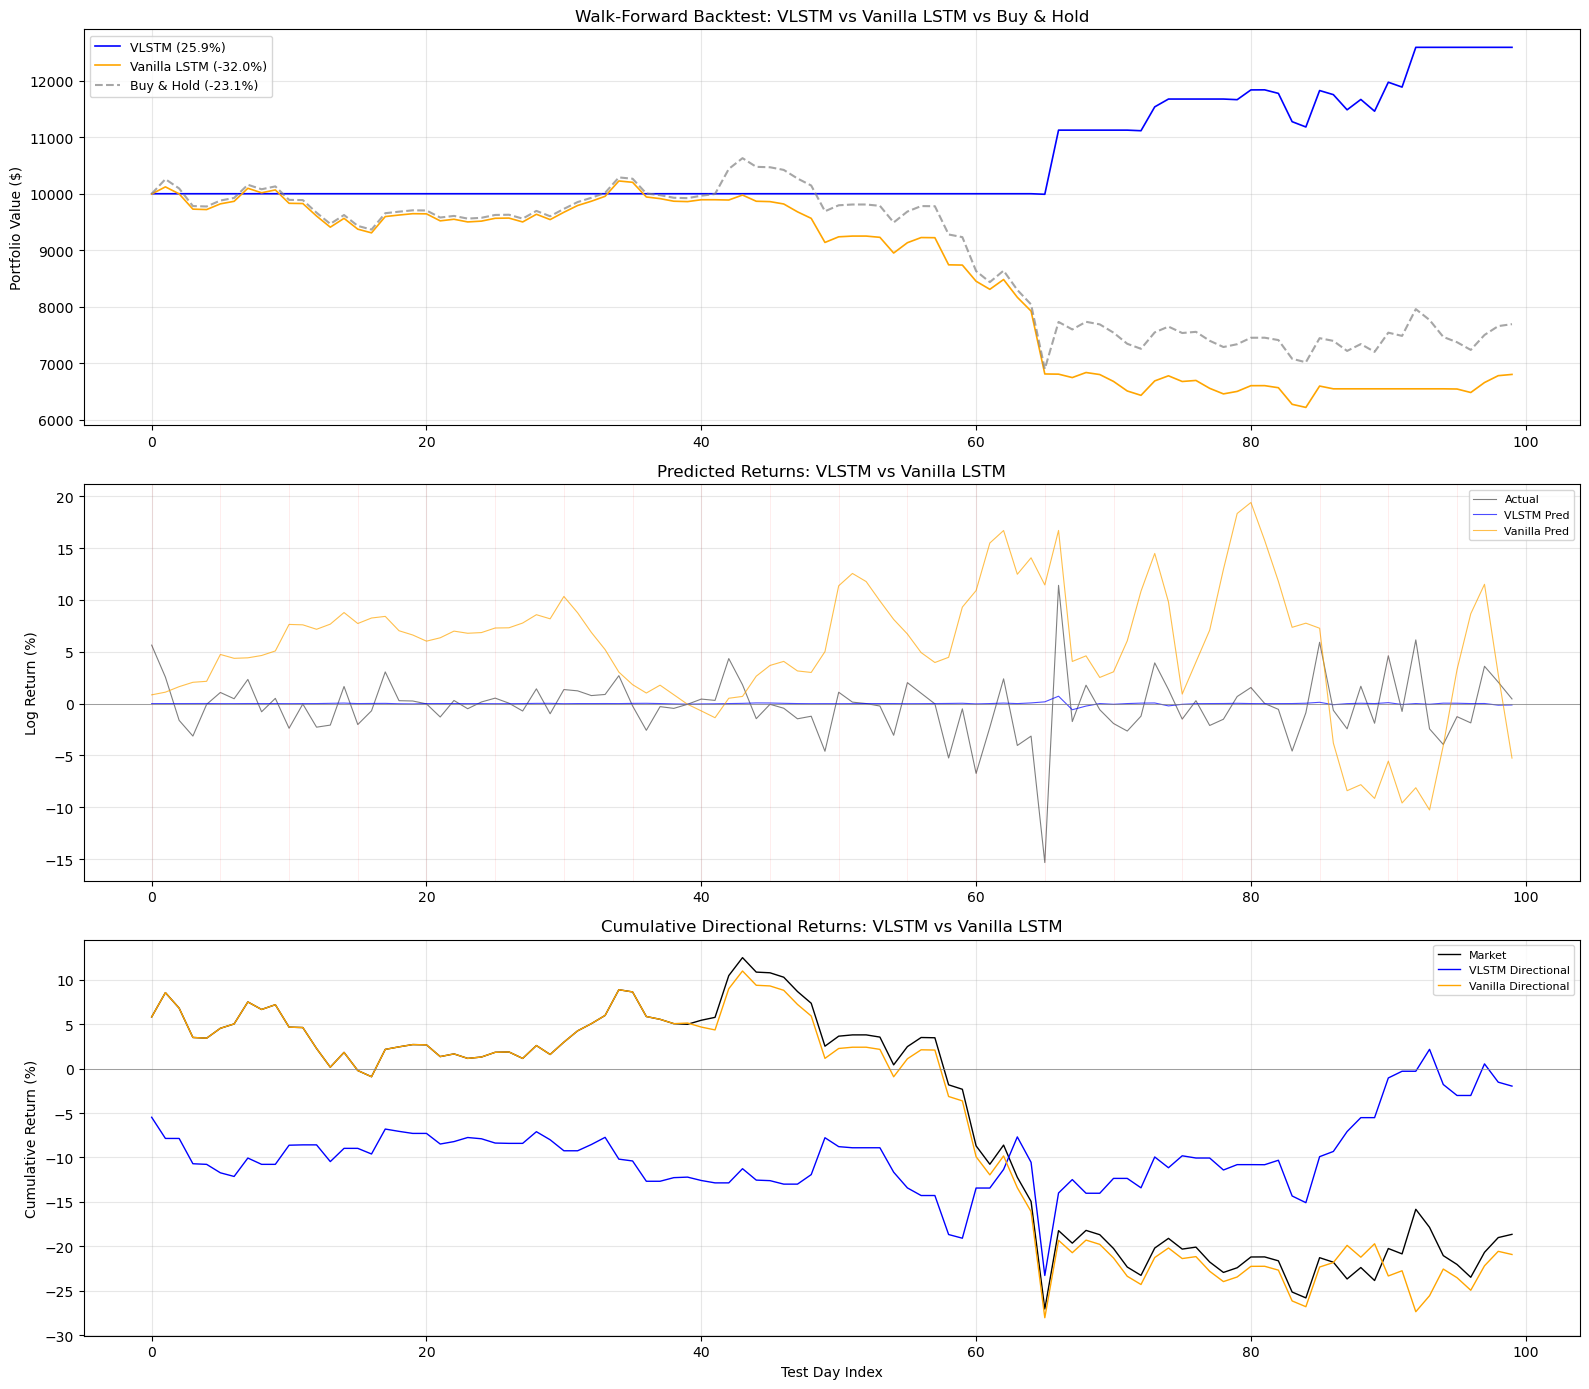

In [ ]:
# vanilla lstm signals
van_threshold = 0.003
van_signals = []
for r in van_pred_returns:
    if r > van_threshold:
        van_signals.append("BUY")
    elif r < -van_threshold:
        van_signals.append("SELL")
    else:
        van_signals.append("HOLD")

# vanila lstm comparisions
van_prices = np.array(van_close_prices)
cash_v, btc_v, entry_v = 10000.0, 0.0, 0.0
van_portfolio = []
for sig, p in zip(van_signals, van_prices):
    if btc_v > 0 and p <= entry_v * (1 - 0.10):
        cash_v += btc_v * p * 0.999; btc_v = entry_v = 0.0
    elif btc_v > 0 and p >= entry_v * (1 + 0.08):
        cash_v += btc_v * p * 0.999; btc_v = entry_v = 0.0
    elif sig == "BUY" and cash_v > 0:
        trade = cash_v * 0.5; bought = trade * 0.999 / p
        if btc_v > 0:
            entry_v = ((btc_v * entry_v) + (bought * p)) / (btc_v + bought)
        else:
            entry_v = p
        btc_v += bought; cash_v -= trade
    elif sig == "SELL" and btc_v > 0:
        cash_v += btc_v * p * 0.999; btc_v = entry_v = 0.0
    van_portfolio.append(cash_v + btc_v * p)
van_portfolio = np.array(van_portfolio)

van_ret = (van_portfolio[-1] / 10000 - 1) * 100
van_daily = np.diff(van_portfolio) / van_portfolio[:-1]
van_sharpe_val = np.sqrt(252) * van_daily.mean() / (van_daily.std() + 1e-10)
van_correct = ((van_pred_returns > 0) == (van_actual_returns > 0)).mean()

vlstm_correct = ((wf_pred_returns > 0) == (wf_actual_returns > 0)).mean()

print("=== Model Comparison ===")
print(f"{'Metric':<25} {'VLSTM':>12} {'Vanilla LSTM':>14}")
print(f"{'-'*53}")
print(f"{'Strategy Return':<25} {wf_model_ret:>11.2f}% {van_ret:>13.2f}%")
print(f"{'Buy & Hold Return':<25} {wf_bh_ret:>11.2f}% {wf_bh_ret:>13.2f}%")
print(f"{'Annualized Sharpe':<25} {wf_sharpe:>12.3f} {van_sharpe_val:>14.3f}")
print(f"{'Max Drawdown':<25} {max_dd:>11.2f}%", end="")
van_peak = np.maximum.accumulate(van_portfolio)
van_dd = ((van_portfolio - van_peak) / van_peak).min() * 100
print(f" {van_dd:>13.2f}%")
print(f"{'Directional Accuracy':<25} {vlstm_correct*100:>11.1f}% {van_correct*100:>13.1f}%")
print(f"{'Signal Dist (VLSTM)':<25} {Counter(wf_signals)}")
print(f"{'Signal Dist (Vanilla)':<25} {Counter(van_signals)}")

─
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# comparision
ax = axes[0]
bh_line = 10000 * wf_prices / wf_prices[0]
ax.plot(wf_portfolio, label=f'VLSTM ({wf_model_ret:.1f}%)', color='blue', linewidth=1.2)
ax.plot(van_portfolio, label=f'Vanilla LSTM ({van_ret:.1f}%)', color='orange', linewidth=1.2)
ax.plot(bh_line, label=f'Buy & Hold ({wf_bh_ret:.1f}%)', color='gray', linestyle='--', alpha=0.7)
ax.set_ylabel('Portfolio Value ($)')
ax.set_title('Walk-Forward Backtest: VLSTM vs Vanilla LSTM vs Buy & Hold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# rreturns 
ax = axes[1]
ax.plot(wf_actual_returns * 100, label='Actual', color='black', alpha=0.5, linewidth=0.8)
ax.plot(wf_pred_returns * 100, label='VLSTM Pred', color='blue', alpha=0.7, linewidth=0.8)
ax.plot(van_pred_returns * 100, label='Vanilla Pred', color='orange', alpha=0.7, linewidth=0.8)
ax.axhline(0, color='gray', linewidth=0.5)
for w in range(0, len(wf_pred_returns), STEP_SIZE):
    ax.axvline(w, color='red', alpha=0.1, linewidth=0.5)
ax.set_ylabel('Log Return (%)')
ax.set_title('Predicted Returns: VLSTM vs Vanilla LSTM')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# directional comparision
ax = axes[2]
cum_actual = np.exp(np.cumsum(wf_actual_returns)) - 1
cum_vlstm = np.exp(np.cumsum(wf_actual_returns * np.sign(wf_pred_returns))) - 1
cum_vanilla = np.exp(np.cumsum(van_actual_returns * np.sign(van_pred_returns))) - 1
ax.plot(cum_actual * 100, label='Market', color='black', linewidth=1)
ax.plot(cum_vlstm * 100, label='VLSTM Directional', color='blue', linewidth=1)
ax.plot(cum_vanilla * 100, label='Vanilla Directional', color='orange', linewidth=1)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Test Day Index')
ax.set_ylabel('Cumulative Return (%)')
ax.set_title('Cumulative Directional Returns: VLSTM vs Vanilla LSTM')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
INITIAL_CAPITAL = 10000.0

def compute_eval_metrics(pred_returns, actual_returns, close_prices, signals, portfolio_values):
    portfolio_values = np.array(portfolio_values, dtype=float)
    final_portfolio_value = portfolio_values[-1]
    bh_final = INITIAL_CAPITAL * (close_prices[-1] / close_prices[0])
    strategy_return = (final_portfolio_value - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
    bh_return = (bh_final - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
    excess_return = strategy_return - bh_return
    trade_log = []
    for sig, p in zip(signals, close_prices):
        if sig in ("BUY", "SELL"):
            trade_log.append({"type": sig, "price": p, "amount_usd": INITIAL_CAPITAL * 0.5})
    total_trades = len(trade_log)
    buys_stack, gross_profits, gross_losses, wins, completed_trades = [], 0.0, 0.0, 0, 0
    for t in trade_log:
        if t["type"] == "BUY":
            buys_stack.append(t)
        elif t["type"] == "SELL" and buys_stack:
            avg_buy = np.mean([b["price"] for b in buys_stack])
            pnl = (t["price"] - avg_buy) / avg_buy
            if pnl > 0:
                gross_profits += t["amount_usd"] * pnl
                wins += 1
            else:
                gross_losses += abs(t["amount_usd"] * pnl)
            completed_trades += 1
            buys_stack = []
    win_rate = (wins / completed_trades * 100) if completed_trades > 0 else 0.0
    profit_factor = (gross_profits / gross_losses) if gross_losses > 0 else float("inf")
    running_max = np.maximum.accumulate(portfolio_values)
    dd = (portfolio_values - running_max) / running_max * 100
    max_drawdown = dd.min()
    daily_returns = np.diff(portfolio_values) / portfolio_values[:-1]
    sharpe_ratio = (np.mean(daily_returns) / (np.std(daily_returns) + 1e-10)) * np.sqrt(252)
    dir_acc = ((pred_returns > 0) == (actual_returns > 0)).mean() * 100
    return {
        "Strategy Return (%)": f"{strategy_return:.2f}",
        "Buy & Hold Return (%)": f"{bh_return:.2f}",
        "Excess Return (%)": f"{excess_return:.2f}",
        "Directional Accuracy (%)": f"{dir_acc:.1f}",
        "Total Trades": f"{total_trades}",
        "Completed Round-Trips": f"{completed_trades}",
        "Win Rate (%)": f"{win_rate:.1f}",
        "Profit Factor": f"{profit_factor:.2f}" if profit_factor != float("inf") else "inf",
        "Max Drawdown (%)": f"{max_drawdown:.2f}",
        "Annualized Sharpe": f"{sharpe_ratio:.3f}",
        "BUY Signals": f"{signals.count('BUY')}",
        "SELL Signals": f"{signals.count('SELL')}",
        "HOLD Signals": f"{signals.count('HOLD')}",
    }

vlstm_m = compute_eval_metrics(wf_pred_returns, wf_actual_returns, wf_close_prices, wf_signals, wf_portfolio)
vanilla_m = compute_eval_metrics(van_pred_returns, van_actual_returns, van_close_prices, van_signals, van_portfolio)

  EVALUATION METRICS: VLSTM vs Vanilla LSTM
                           VLSTM Vanilla LSTM
Metric                                       
Strategy Return (%)        25.93       -32.00
Buy & Hold Return (%)     -23.10       -23.10
Excess Return (%)          49.02        -8.90
Directional Accuracy (%)    49.0         46.0
Total Trades                  10           99
Completed Round-Trips          2            3
Win Rate (%)               100.0         66.7
Profit Factor                inf         0.36
Max Drawdown (%)           -5.55       -39.22
Annualized Sharpe          2.403       -2.611
BUY Signals                    6           87
SELL Signals                   4           12
HOLD Signals                  90            1


,VLSTM,Vanilla LSTM
Metric,,
Strategy Return (%),25.93,-32.00
Buy & Hold Return (%),-23.10,-23.10
Excess Return (%),49.02,-8.90
Directional Accuracy (%),49.0,46.0
Total Trades,10,99
Completed Round-Trips,2,3
Win Rate (%),100.0,66.7
Profit Factor,inf,0.36
Max Drawdown (%),-5.55,-39.22


In [85]:
class LossBasket():
    def __init__(self):
        pass
    def information_coefficient_loss(self, pred, actual):
        pred_norm = (pred - pred.mean()) / (pred.std() + 1e-10)
        actual_norm = (actual - actual.mean()) / (actual.std() + 1e-10)
        ic = ((pred_norm * actual_norm).mean())
        mse = F.mse_loss(pred.squeeze(), actual.squeeze())
        return mse - 0.5 * ic

    def directional_loss(self, pred, actual):
        direction_pred = torch.tanh(pred.squeeze()) 
        direction_actual = torch.sign(actual.squeeze())  
        dir_loss = F.mse_loss(direction_pred, direction_actual)
        mag_loss = F.mse_loss(pred.squeeze(), actual.squeeze())
        
        return 0.7 * dir_loss + 0.3 * mag_loss
    

In [ ]:
# FIX 2: Adaptive position sizing with NaN-safe scaling

def rolling_std_safe(values, window):
    series = pd.Series(np.asarray(values, dtype=float))
    rolling = series.rolling(window, min_periods=2).std(ddof=0)
    fallback = series.std(ddof=0)
    if not np.isfinite(fallback):
        fallback = 0.0
    return rolling.bfill().fillna(fallback).to_numpy(dtype=float)


def build_position_sizes(pred_returns, window=10, min_size=0.10, max_size=0.75):
    pred_returns = np.asarray(pred_returns, dtype=float)
    pred_vol = rolling_std_safe(pred_returns, window)
    strength = np.abs(pred_returns) / np.maximum(pred_vol, 1e-6)
    scale = np.nanpercentile(strength, 80)
    if not np.isfinite(scale) or scale <= 0:
        normalized = np.zeros_like(strength)
    else:
        normalized = np.clip(strength / scale, 0.0, 1.0)
    sizes = min_size + (max_size - min_size) * normalized
    return sizes, pred_vol, strength


wf_positions, wf_pred_vol, wf_signal_strength = build_position_sizes(wf_pred_returns, window=10)


Fix 2 ready: adaptive position sizing
  Mean position size: 45.5%
  Position range: 10.0% to 75.0%
  NaN count: 0


In [44]:
# FIX 3: Volatility-adjusted signals using forecast z-scores

def generate_adaptive_signals(pred_returns, pred_vol=None, window=20, z_threshold=0.35):
    pred_returns = np.asarray(pred_returns, dtype=float)
    if pred_vol is None:
        pred_vol = rolling_std_safe(pred_returns, window)

    z_scores = pred_returns / np.maximum(pred_vol, 1e-6)
    signals = []
    for index, z_score in enumerate(z_scores):
        if index < window:
            signals.append("HOLD")
        elif z_score > z_threshold:
            signals.append("BUY")
        elif z_score < -z_threshold:
            signals.append("SELL")
        else:
            signals.append("HOLD")

    return signals, z_scores


wf_adaptive_signals, wf_signal_score = generate_adaptive_signals(
    wf_pred_returns, pred_vol=wf_pred_vol, window=20, z_threshold=0.35
)

print("Fix 3 ready: adaptive signals")
print(f"  Adaptive signals: {Counter(wf_adaptive_signals)}")
print(f"  Original signals: {Counter(wf_signals)}")

Fix 3 ready: adaptive signals
  Adaptive signals: Counter({'BUY': 65, 'HOLD': 30, 'SELL': 5})
  Original signals: Counter({'SELL': 100})


In [86]:
# FIX 4: Replace broken short accounting with a signed-exposure backtest

def signals_to_positions(signals, sizes, allow_short=True):
    signals = np.asarray(signals)
    sizes = np.asarray(sizes, dtype=float)
    positions = np.zeros(len(signals), dtype=float)
    current_position = 0.0

    for index, signal in enumerate(signals):
        if signal == "BUY":
            current_position = sizes[index]
        elif signal == "SELL":
            current_position = -sizes[index] if allow_short else 0.0
        positions[index] = current_position

    return positions


def run_fractional_backtest(close_prices, target_positions, initial_capital=10000.0, fee_bps=10):
    prices = np.asarray(close_prices, dtype=float)
    positions = np.asarray(target_positions, dtype=float)

    if len(prices) != len(positions):
        raise ValueError("close_prices and target_positions must have the same length")

    portfolio = np.empty(len(prices), dtype=float)
    turnover = np.zeros(len(prices), dtype=float)
    portfolio[0] = initial_capital

    for index in range(1, len(prices)):
        asset_return = prices[index] / prices[index - 1] - 1.0
        turnover[index] = abs(positions[index] - positions[index - 1])
        transaction_cost = (fee_bps / 10000.0) * turnover[index]
        portfolio[index] = portfolio[index - 1] * (
            1.0 + positions[index - 1] * asset_return - transaction_cost
        )

    return portfolio, turnover


wf_positions_long_only = signals_to_positions(wf_adaptive_signals, wf_positions, allow_short=False)
wf_positions_shortable = signals_to_positions(wf_adaptive_signals, wf_positions, allow_short=True)

wf_portfolio_long_only_fixed, wf_turnover_long_only = run_fractional_backtest(
    wf_close_prices, wf_positions_long_only
)
wf_portfolio_shorts, wf_turnover_shorts = run_fractional_backtest(
    wf_close_prices, wf_positions_shortable
)

wf_ret_long_only_fixed = (wf_portfolio_long_only_fixed[-1] / 10000.0 - 1.0) * 100
wf_ret_shorts = (wf_portfolio_shorts[-1] / 10000.0 - 1.0) * 100
bh_ret_shorts = (wf_close_prices[-1] / wf_close_prices[0] - 1.0) * 100

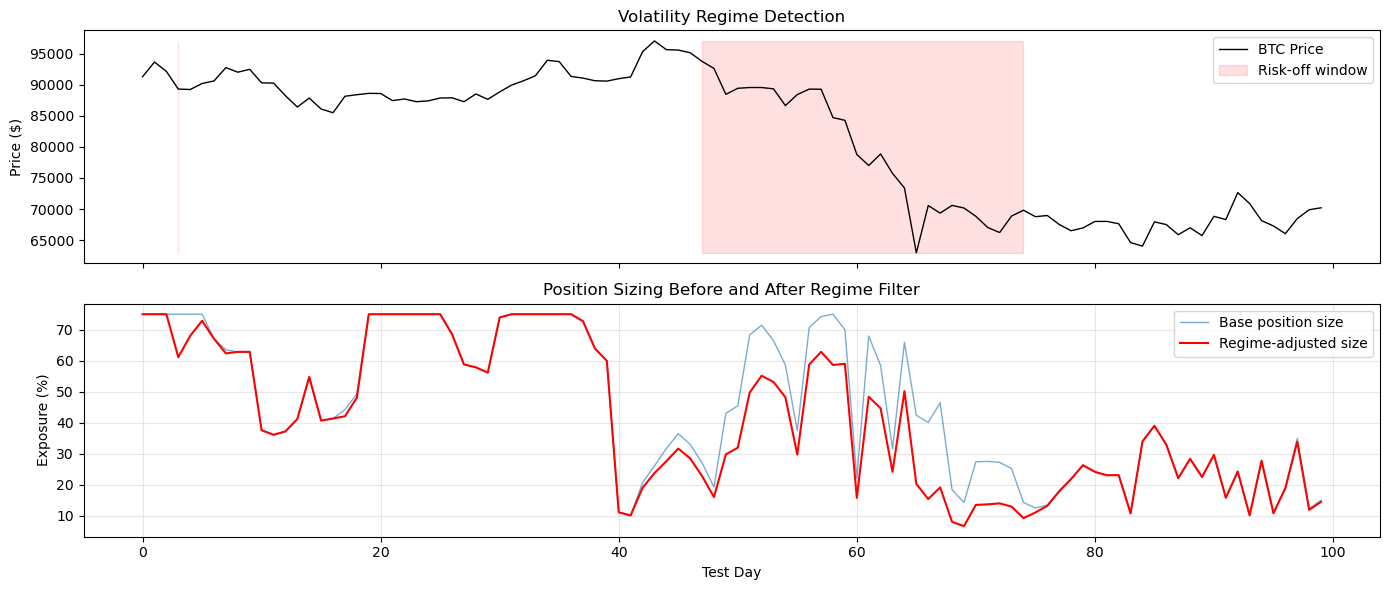

In [87]:
# de risking at volatitlity spikes
def compute_regime_scores(close_prices, window=20, floor=0.35):
    prices = np.asarray(close_prices, dtype=float)
    log_returns = np.diff(np.log(prices), prepend=np.log(prices[0]))
    realized_vol = rolling_std_safe(log_returns, window)

    baseline = pd.Series(realized_vol).rolling(window, min_periods=5).median()
    baseline = baseline.bfill().fillna(np.nanmedian(realized_vol))
    baseline_values = np.maximum(baseline.to_numpy(dtype=float), 1e-6)

    vol_ratio = realized_vol / baseline_values
    regime_scores = 1.0 / np.maximum(vol_ratio, 1.0)
    regime_scores = np.clip(regime_scores, floor, 1.0)
    return regime_scores, realized_vol, vol_ratio


wf_regime_scores, wf_realized_vol, wf_vol_ratio = compute_regime_scores(wf_close_prices, window=20)
wf_positions_adjusted = wf_positions * wf_regime_scores
wf_positions_final = signals_to_positions(wf_adaptive_signals, wf_positions_adjusted, allow_short=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax = axes[0]
ax.plot(wf_close_prices, label="BTC Price", color="black", linewidth=1)
risk_off = wf_regime_scores < 0.85
ax.fill_between(
    range(len(wf_close_prices)),
    wf_close_prices.min(),
    wf_close_prices.max(),
    where=risk_off,
    alpha=0.12,
    color="red",
    label="Risk-off window"
)
ax.set_ylabel("Price ($)")
ax.set_title("Volatility Regime Detection")
ax.legend()

ax = axes[1]
ax.plot(wf_positions * 100, label="Base position size", alpha=0.6, linewidth=1)
ax.plot(wf_positions_adjusted * 100, label="Regime-adjusted size", color="red", linewidth=1.5)
ax.set_ylabel("Exposure (%)")
ax.set_xlabel("Test Day")
ax.set_title("Position Sizing Before and After Regime Filter")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def compute_strategy_metrics(portfolio, close_prices, pred_returns, actual_returns):
    portfolio = np.asarray(portfolio, dtype=float)
    close_prices = np.asarray(close_prices, dtype=float)
    pred_returns = np.asarray(pred_returns, dtype=float)
    actual_returns = np.asarray(actual_returns, dtype=float)

    if np.isnan(portfolio).any():
        raise ValueError("Portfolio contains NaN values")

    strategy_return = (portfolio[-1] / portfolio[0] - 1.0) * 100
    bh_return = (close_prices[-1] / close_prices[0] - 1.0) * 100
    daily_returns = np.diff(portfolio) / np.maximum(portfolio[:-1], 1e-8)
    if len(daily_returns) == 0 or np.isclose(daily_returns.std(), 0.0):
        sharpe = 0.0
    else:
        sharpe = np.sqrt(252) * daily_returns.mean() / daily_returns.std()
    peak = np.maximum.accumulate(portfolio)
    max_drawdown = ((portfolio - peak) / np.maximum(peak, 1e-8)).min() * 100
    directional_accuracy = ((pred_returns > 0) == (actual_returns > 0)).mean() * 100

    return {
        "Return (%)": strategy_return,
        "B&H Return (%)": bh_return,
        "Sharpe": sharpe,
        "Max DD (%)": max_drawdown,
        "Dir Acc (%)": directional_accuracy,
    }


if "wf_positions_final" not in globals():
    wf_regime_scores, wf_realized_vol, wf_vol_ratio = compute_regime_scores(wf_close_prices, window=20)
    wf_positions_adjusted = wf_positions * wf_regime_scores
    wf_positions_final = signals_to_positions(wf_adaptive_signals, wf_positions_adjusted, allow_short=True)

van_positions, van_pred_vol, van_signal_strength = build_position_sizes(van_pred_returns, window=10)
van_adaptive_signals, van_signal_score = generate_adaptive_signals(
    van_pred_returns, pred_vol=van_pred_vol, window=20, z_threshold=0.35
)
van_regime_scores, van_realized_vol, van_vol_ratio = compute_regime_scores(van_close_prices, window=20)
van_positions_adjusted = van_positions * van_regime_scores
van_positions_final = signals_to_positions(van_adaptive_signals, van_positions_adjusted, allow_short=True)

wf_portfolio_all_fixes, wf_turnover = run_fractional_backtest(wf_close_prices, wf_positions_final)
van_portfolio_all_fixes, van_turnover = run_fractional_backtest(van_close_prices, van_positions_final)

vlstm_orig = compute_strategy_metrics(wf_portfolio, wf_close_prices, wf_pred_returns, wf_actual_returns)
vlstm_fixes = compute_strategy_metrics(wf_portfolio_all_fixes, wf_close_prices, wf_pred_returns, wf_actual_returns)
van_orig = compute_strategy_metrics(van_portfolio, van_close_prices, van_pred_returns, van_actual_returns)
van_fixes = compute_strategy_metrics(van_portfolio_all_fixes, van_close_prices, van_pred_returns, van_actual_returns)

comp_df = pd.DataFrame(
    [vlstm_orig, vlstm_fixes, van_orig, van_fixes],
    index=["VLSTM Original", "VLSTM + Fixes", "Vanilla Original", "Vanilla + Fixes"],
)

print("\n" + "=" * 84)
print("STABLE COMPARISON: ORIGINAL VS FIXED BACKTESTS")
print("=" * 84)
print(comp_df.round(2).to_string())
print("=" * 84)
print(f"VLSTM adaptive signals: {Counter(wf_adaptive_signals)}")
print(f"Vanilla adaptive signals: {Counter(van_adaptive_signals)}")
print(f"VLSTM avg turnover: {wf_turnover.mean():.3f}")
print(f"Vanilla avg turnover: {van_turnover.mean():.3f}")


STABLE COMPARISON: ORIGINAL VS FIXED BACKTESTS
                  Return (%)  B&H Return (%)  Sharpe  Max DD (%)  Dir Acc (%)
VLSTM Original         25.93           -23.1    2.40       -5.55         49.0
VLSTM + Fixes         -11.79           -23.1   -1.71      -17.25         49.0
Vanilla Original      -31.96           -23.1   -2.61      -39.22         46.0
Vanilla + Fixes        -9.05           -23.1   -1.63      -15.34         46.0
VLSTM adaptive signals: Counter({'BUY': 65, 'HOLD': 30, 'SELL': 5})
Vanilla adaptive signals: Counter({'BUY': 63, 'HOLD': 26, 'SELL': 11})
VLSTM avg turnover: 0.087
Vanilla avg turnover: 0.060


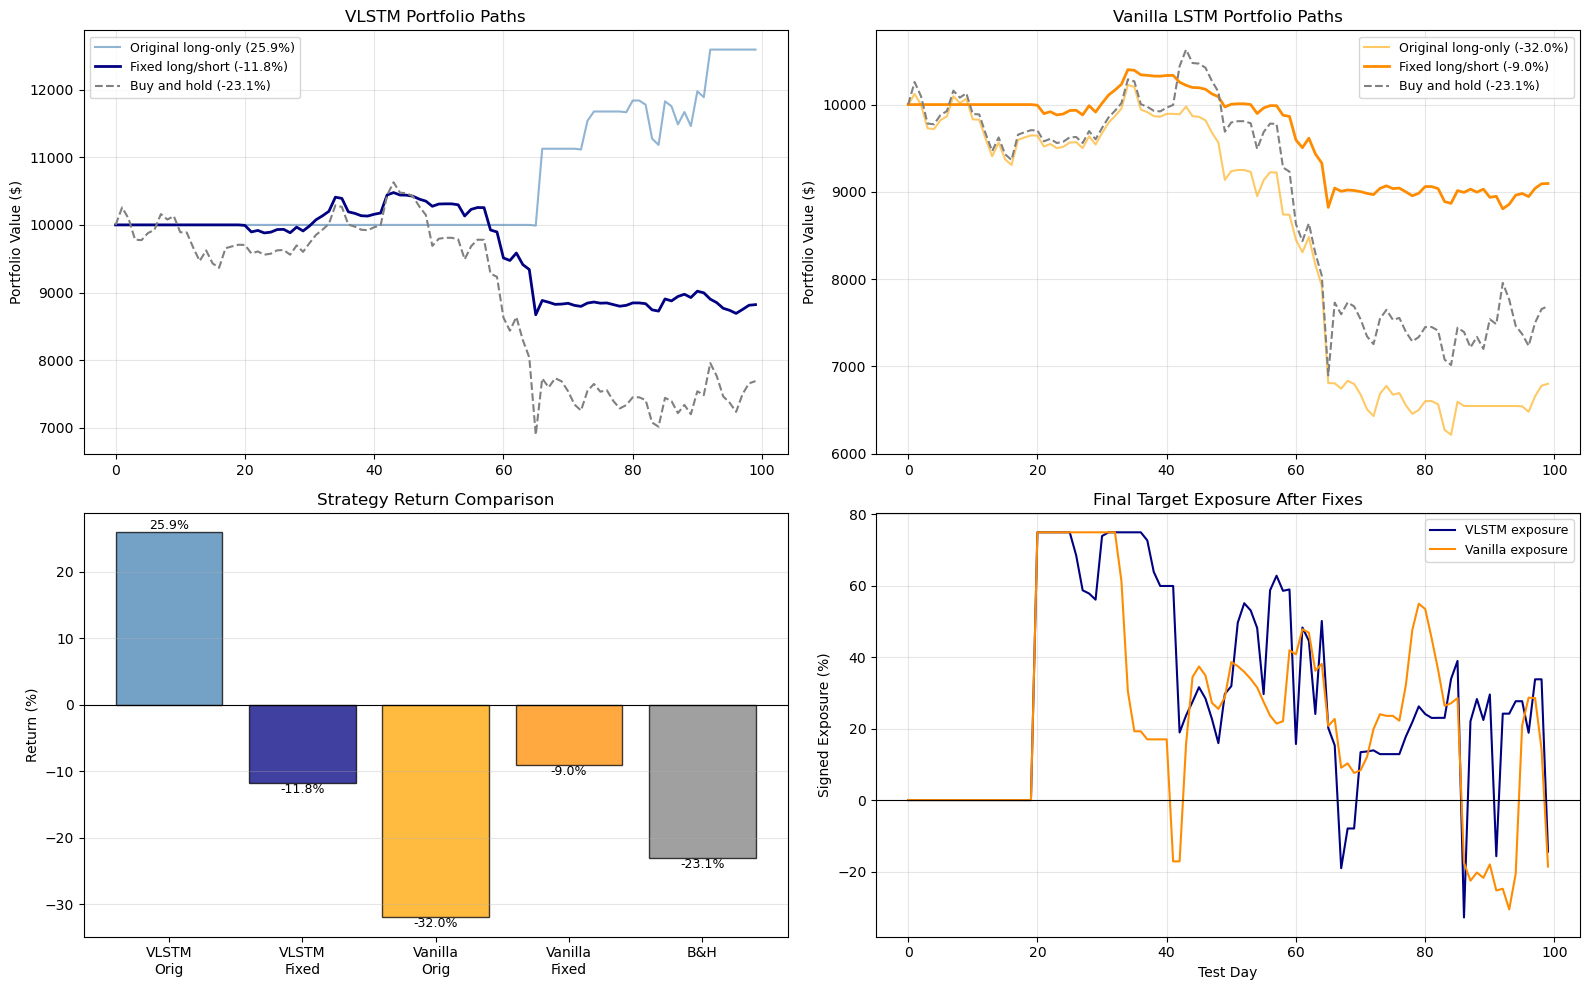

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

bh_line = 10000 * wf_close_prices / wf_close_prices[0]

ax = axes[0, 0]
ax.plot(wf_portfolio, label=f"Original long-only ({vlstm_orig['Return (%)']:.1f}%)", color="steelblue", alpha=0.6)
ax.plot(wf_portfolio_all_fixes, label=f"Fixed long/short ({vlstm_fixes['Return (%)']:.1f}%)", color="navy", linewidth=2)
ax.plot(bh_line, label=f"Buy and hold ({vlstm_orig['B&H Return (%)']:.1f}%)", color="gray", linestyle="--")
ax.set_ylabel("Portfolio Value ($)")
ax.set_title("VLSTM Portfolio Paths")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(van_portfolio, label=f"Original long-only ({van_orig['Return (%)']:.1f}%)", color="orange", alpha=0.6)
ax.plot(van_portfolio_all_fixes, label=f"Fixed long/short ({van_fixes['Return (%)']:.1f}%)", color="darkorange", linewidth=2)
ax.plot(bh_line, label=f"Buy and hold ({van_orig['B&H Return (%)']:.1f}%)", color="gray", linestyle="--")
ax.set_ylabel("Portfolio Value ($)")
ax.set_title("Vanilla LSTM Portfolio Paths")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1, 0]
strategy_labels = ["VLSTM\nOrig", "VLSTM\nFixed", "Vanilla\nOrig", "Vanilla\nFixed", "B&H"]
strategy_returns = [
    vlstm_orig["Return (%)"],
    vlstm_fixes["Return (%)"],
    van_orig["Return (%)"],
    van_fixes["Return (%)"],
    vlstm_orig["B&H Return (%)"],
]
colors = ["steelblue", "navy", "orange", "darkorange", "gray"]
bars = ax.bar(strategy_labels, strategy_returns, color=colors, alpha=0.75, edgecolor="black")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Return (%)")
ax.set_title("Strategy Return Comparison")
for bar, value in zip(bars, strategy_returns):
    va = "bottom" if value >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.1f}%", ha="center", va=va, fontsize=9)
ax.grid(alpha=0.3, axis="y")

ax = axes[1, 1]
ax.plot(wf_positions_final * 100, label="VLSTM exposure", color="navy", linewidth=1.5)
ax.plot(van_positions_final * 100, label="Vanilla exposure", color="darkorange", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Signed Exposure (%)")
ax.set_xlabel("Test Day")
ax.set_title("Final Target Exposure After Fixes")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()